# 04 – Baseline Model Development

This notebook trains three classifiers on the preprocessed, under-sampled data to establish performance benchmarks. No hyperparameter tuning is applied — the aim is to characterise the natural performance ceiling of each model family before optimisation, and to identify which warrants further tuning in Notebook 05.

**Models trained:**
- **Logistic Regression** — interpretable linear baseline; establishes the floor for linear models
- **Decision Tree (unregularised)** — demonstrates overfitting without depth constraints
- **Random Forest (100 trees, default)** — ensemble baseline via bagging and feature subsampling


## Imports

In [11]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix,
    classification_report
)

from imblearn.under_sampling import RandomUnderSampler

BASE_DIR = Path("..").resolve()
PROCESSED_DIR = BASE_DIR / "data" / "processed"

## Load Processed Data

Preprocessed features and binary target labels are loaded from Notebook 02 outputs.

In [2]:
X = pd.read_csv(PROCESSED_DIR / "cell2celltrain_processed.csv")
y = pd.read_csv(PROCESSED_DIR / "cell2celltrain_target.csv").squeeze("columns")

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (51047, 50)
Target shape: (51047,)


## Train-Test Split

80/20 stratified split (`random_state=42`), consistent with Notebook 03.


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training set:", X_train.shape)
print("Test set:    ", X_test.shape)

Training set: (40837, 50)
Test set:     (10210, 50)


## Apply Random Under-Sampling

Selected in Notebook 03 as the best-performing imbalance strategy. Applied to the training split only — the test set retains the original class distribution to reflect real-world conditions.

In [4]:
rus = RandomUnderSampler(random_state=42)
X_train_res, y_train_res = rus.fit_resample(X_train, y_train)

print("Before under-sampling:", X_train.shape)
print("After under-sampling: ", X_train_res.shape)
print("\nClass distribution after resampling:")
print(pd.Series(y_train_res).value_counts())

Before under-sampling: (40837, 50)
After under-sampling:  (23538, 50)

Class distribution after resampling:
Churn
0    11769
1    11769
Name: count, dtype: int64


## Evaluation Function

Computes Precision, Recall, F1-score, ROC-AUC, and Confusion Matrix. A consistent function across all models ensures results are directly comparable.

In [5]:
def evaluate_model(name, model, X_test, y_test):
    """Evaluate a fitted classifier and print a formatted results summary."""
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    precision = precision_score(y_test, y_pred, zero_division=0)
    recall    = recall_score(y_test, y_pred, zero_division=0)
    f1        = f1_score(y_test, y_pred, zero_division=0)
    roc_auc   = roc_auc_score(y_test, y_prob)
    cm        = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    print(f"=== {name} ===")
    print(f"  Precision : {precision:.4f}")
    print(f"  Recall    : {recall:.4f}")
    print(f"  F1-score  : {f1:.4f}")
    print(f"  ROC-AUC   : {roc_auc:.4f}")
    print(f"  Confusion Matrix:")
    print(f"    TN={tn}  FP={fp}")
    print(f"    FN={fn}  TP={tp}")
    print()

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"], zero_division=0))

    return {
        "Precision": round(precision, 4),
        "Recall":    round(recall, 4),
        "F1-score":  round(f1, 4),
        "ROC-AUC":   round(roc_auc, 4),
        "Confusion Matrix": cm
    }

## Model 1 — Logistic Regression

Logistic Regression with L2 regularisation (`C=1.0`, `max_iter=2000`). Serves as the primary interpretable baseline — establishes the performance floor for linear models.


In [6]:
results = {}

lr = LogisticRegression(max_iter=2000, random_state=42)
lr.fit(X_train_res, y_train_res)

results["Logistic Regression"] = evaluate_model(
    "Logistic Regression", lr, X_test, y_test
)

=== Logistic Regression ===
  Precision : 0.3603
  Recall    : 0.5761
  F1-score  : 0.4434
  ROC-AUC   : 0.6117
  Confusion Matrix:
    TN=4259  FP=3009
    FN=1247  TP=1695


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.77      0.59      0.67      7268
       Churn       0.36      0.58      0.44      2942

    accuracy                           0.58     10210
   macro avg       0.57      0.58      0.56     10210
weighted avg       0.65      0.58      0.60     10210



Logistic Regression achieves an F1-score of 0.4434 and ROC-AUC of 0.6117. Recall (0.576) indicates that the model identifies just over half of all churners in the test set — an improvement over the unhandled baseline's 0.033 confirmed in Notebook 03, but still leaving 1,247 churners undetected. The relatively low ROC-AUC (0.612) suggests the model's linear decision boundary captures only weak separability between the two classes, which is expected given the likely non-linear nature of churn behaviour across 50 features.

## Model 2 — Decision Tree (Unregularised)

A Decision Tree is trained with no depth limit or leaf-size constraints — all hyperparameters are left at their default values. This is an intentional design choice: an unconstrained tree will grow until every training sample is classified perfectly, demonstrating the pathological overfitting that arises without regularisation. The resulting test-set performance is expected to be poor, establishing a clear lower bound and motivating the depth-constrained tuning performed in Notebook 05. This also illustrates directly why ensemble methods such as Random Forest — which introduce implicit regularisation through bagging — are more effective than a single unrestricted tree.

In [7]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_res, y_train_res)

results["Decision Tree"] = evaluate_model(
    "Decision Tree", dt, X_test, y_test
)

=== Decision Tree ===
  Precision : 0.3315
  Recall    : 0.5469
  F1-score  : 0.4128
  ROC-AUC   : 0.5502
  Confusion Matrix:
    TN=4023  FP=3245
    FN=1333  TP=1609


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.75      0.55      0.64      7268
       Churn       0.33      0.55      0.41      2942

    accuracy                           0.55     10210
   macro avg       0.54      0.55      0.53     10210
weighted avg       0.63      0.55      0.57     10210



The unregularised Decision Tree performs as expected: its ROC-AUC of 0.5502 is only marginally above random chance (0.5), confirming that the model has memorised the training data without generalising to unseen records. F1 (0.4128) and recall (0.547) are both lower than Logistic Regression — the unconstrained tree sacrifices generalisation performance entirely for training set fit. This result validates the need for regularisation, which is introduced through hyperparameter tuning (Notebook 05) and through the ensemble approach of Random Forest below.

## Model 3 — Random Forest

An ensemble of 100 trees trained via bagging with feature subsampling at each split. These mechanisms decorrelate the trees, reducing the overfitting seen in the single Decision Tree without requiring explicit depth constraints.

In [8]:
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
rf.fit(X_train_res, y_train_res)

results["Random Forest"] = evaluate_model(
    "Random Forest", rf, X_test, y_test
)

=== Random Forest ===
  Precision : 0.3871
  Recall    : 0.6261
  F1-score  : 0.4784
  ROC-AUC   : 0.6542
  Confusion Matrix:
    TN=4352  FP=2916
    FN=1100  TP=1842


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.80      0.60      0.68      7268
       Churn       0.39      0.63      0.48      2942

    accuracy                           0.61     10210
   macro avg       0.59      0.61      0.58     10210
weighted avg       0.68      0.61      0.62     10210



Random Forest substantially outperforms both individual classifiers: F1 improves to 0.4784 and ROC-AUC to 0.6542 — approximately 10 points above the unregularised Decision Tree. Recall rises to 0.626, meaning that 1,842 churners are correctly identified compared to 1,609 for the Decision Tree and 1,695 for Logistic Regression. The ensemble mechanism — bootstrapped sampling of training records and random feature subsampling at each split — decorrelates the individual trees, reducing variance without the explicit depth constraints required by a single tree. The improvement in all four metrics confirms the architectural advantage of ensemble methods for this classification task.

## Baseline Model Comparison

All three baseline models are compiled into a summary table for direct comparison. Results are saved to disk for reference in Notebooks 05 and 06.

In [9]:
summary = pd.DataFrame(
    {
        name: {
            metric: metrics[metric]
            for metric in ["Precision", "Recall", "F1-score", "ROC-AUC"]
        }
        for name, metrics in results.items()
    }
).T

print("=== Baseline Model Comparison ===")
print(summary.to_string())

# Save results for reference in later notebooks
summary.to_csv(PROCESSED_DIR / "notebook04_results.csv")
print("\nResults saved to:", PROCESSED_DIR / "notebook04_results.csv")

=== Baseline Model Comparison ===
                     Precision  Recall  F1-score  ROC-AUC
Logistic Regression     0.3603  0.5761    0.4434   0.6117
Decision Tree           0.3315  0.5469    0.4128   0.5502
Random Forest           0.3871  0.6261    0.4784   0.6542

Results saved to: /Users/abbasq/Uni/third-year/IP/data/processed/notebook04_results.csv


## Confusion Matrices

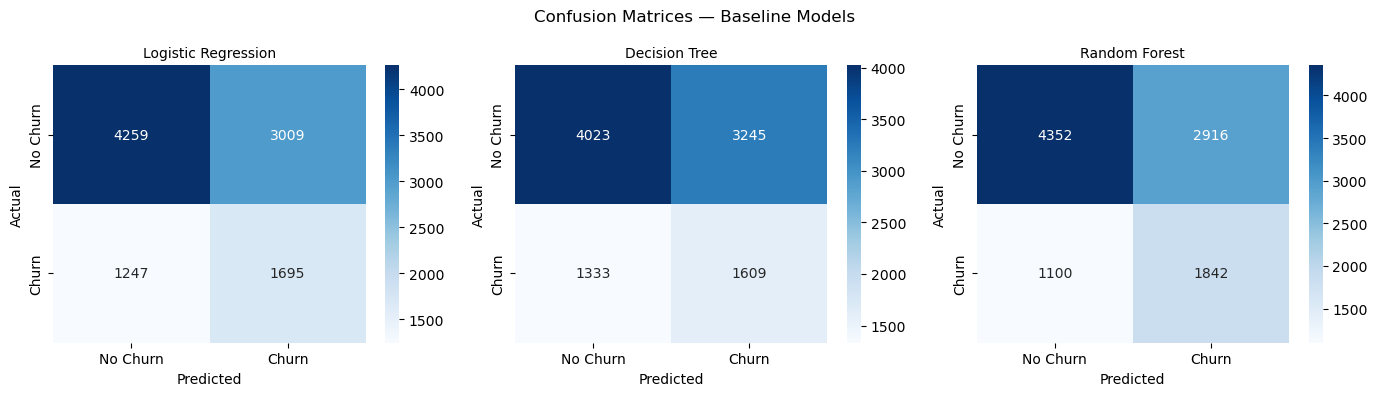

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (name, metrics) in zip(axes, results.items()):
    cm = metrics["Confusion Matrix"]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=["No Churn", "Churn"],
                yticklabels=["No Churn", "Churn"])
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices — Baseline Models", fontsize=12)
plt.tight_layout()
plt.show()

## Key Observations and Model Selection

| Model | Precision | Recall | F1-score | ROC-AUC | Missed Churners (FN) |
|---|---|---|---|---|---|
| Logistic Regression | 0.3603 | 0.5761 | 0.4434 | 0.6117 | 1,247 |
| Decision Tree | 0.3315 | 0.5469 | 0.4128 | 0.5502 | 1,333 |
| **Random Forest** | **0.3871** | **0.6261** | **0.4784** | **0.6542** | **1,100** |

The results illustrate two distinct failure modes. Logistic Regression is limited by its linear decision boundary: it reaches approximately 0.61 ROC-AUC regardless of regularisation strength, indicating that the classes are not linearly separable in this feature space. The unregularised Decision Tree suffers from the opposite problem — high training-set fit but near-random generalisation (ROC-AUC: 0.550) — confirming that unconstrained tree growth produces severe overfitting.

Random Forest is the clear winner across all four metrics and produces the fewest missed churners (1,100 vs 1,247 and 1,333). Bagging reduces variance without requiring explicit depth constraints, and feature subsampling further decorrelates the ensemble. These mechanisms explain the consistent advantage over both individual classifiers.

**Random Forest is carried forward as the baseline benchmark.** Hyperparameter tuning in Notebook 05 will determine whether the default Random Forest configuration can be meaningfully improved, and whether XGBoost (Notebook 06) offers a further architectural advantage.